In [6]:
"""Small PPO demo for PoisonedAppleEnv.

Usage:
    python rl_project/experiments/poisoned_apple/demo_ppo_poisoned_apple.py \
        --timesteps 15000 --render human

Optional trajectory plot (requires matplotlib):
    python rl_project/experiments/poisoned_apple/demo_ppo_poisoned_apple.py \
        --timesteps 15000 --plot-trajectory --save-dir /tmp/poisoned_apple_demo
"""

from __future__ import annotations

import argparse
import os
import sys
from typing import Any

import torch

# # Make rl_project importable when running this file directly.
# _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
# _RL_PROJECT_DIR = os.path.abspath(os.path.join(_THIS_DIR, "..", ".."))
# if _RL_PROJECT_DIR not in sys.path:
#     sys.path.insert(0, _RL_PROJECT_DIR)
sys.path.insert(0, '/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/poisoned_apple')
sys.path.insert(0, '/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project')

from poisoned_apple_env import PoisonedAppleEnv, visualize_agent_trajectory  # noqa: E402
from utils.ppo_utils import PPOConfig, evaluate, ppo_train  # noqa: E402


def build_env(render_mode: str | None = None) -> PoisonedAppleEnv:
    """Create a deterministic poisoned-apple task used for train/eval/render."""
    return PoisonedAppleEnv(
        grid_size=6,
        agent_start_pos=(5, 0),
        safe_apple_positions=[
            (0, 5), 
            (2, 2), 
            # (5, 5)
        ],
        poisoned_apple_positions=[(1, 3), (4, 2)],
        observation_type="flat",
        max_steps=30,
        reward_safe=1.0,
        reward_poison=-1.0,
        reward_step=-0.01,
        render_mode=render_mode,
    )


def train_policy(total_timesteps: int, seed: int, device: str) -> tuple[torch.nn.Module, Any]:
    """Train PPO on PoisonedAppleEnv using repo PPO utilities."""
    env = build_env(render_mode=None)
    cfg = PPOConfig(
        seed=seed,
        total_timesteps=total_timesteps,
        eval_episodes=50,
        rollout_steps=256,
        update_epochs=6,
        minibatch_size=64,
        lr=3e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_coef=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        device=device,
    )
    actor, critic = ppo_train(env=env, cfg=cfg)
    return actor, critic


def rollout_and_render(
    actor: torch.nn.Module,
    seed: int,
    render_mode: str,
    max_steps: int,
) -> None:
    """Run one deterministic rollout and render each step."""
    env = build_env(render_mode=render_mode)
    obs, info = env.reset(seed=seed)
    done = False
    step = 0
    total_reward = 0.0
    unsafe_steps = 0

    actor.eval()
    actor_device = next(actor.parameters()).device

    print("\n--- Deterministic rollout ---")
    print(f"start_info={info}")

    if render_mode == "human":
        env.render()

    while not done and step < max_steps:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=actor_device).unsqueeze(0)
        with torch.no_grad():
            logits = actor(obs_t)
            action = int(torch.argmax(logits, dim=-1).item())

        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        total_reward += float(reward)
        if not info.get("safe", True):
            unsafe_steps += 1

        step += 1
        print(
            f"step={step:02d} action={action} reward={reward:+.2f} "
            f"safe={info.get('safe')} cost={info.get('cost')} "
            f"safe_remaining={info.get('safe_apples_remaining')} "
            f"poison_remaining={info.get('poisoned_apples_remaining')}"
        )

        if render_mode == "human":
            env.render()

    print(
        f"rollout_done steps={step} total_reward={total_reward:.2f} "
        f"unsafe_steps={unsafe_steps} terminated={terminated} truncated={truncated}"
    )
    env.close()


def maybe_plot_trajectory(
    actor: torch.nn.Module,
    save_dir: str | None,
    cfg_name: str,
) -> None:
    """Plot a trajectory using poisoned_apple_env utility (matplotlib required)."""
    try:
        env_plot = build_env(render_mode=None)
        visualize_agent_trajectory(
            env=env_plot,
            actor=actor,
            num_episodes=1,
            env_name="PoisonedApple",
            cfg_name=cfg_name,
            actor_name="PPO",
            save_dir=save_dir,
        )
        env_plot.close()
    except ModuleNotFoundError as exc:
        print(f"Skipping trajectory plot: {exc}")


Use PGD: False
Steps=2560 | meanR=-0.3 +/- 0.0 | elapsed=2.8s | failure_rate=0.00
Steps=5120 | meanR=1.9 +/- 0.0 | elapsed=5.6s | failure_rate=0.00
Steps=7680 | meanR=1.9 +/- 0.0 | elapsed=8.3s | failure_rate=0.00
Steps=10240 | meanR=1.9 +/- 0.0 | elapsed=11.0s | failure_rate=0.00
Steps=12800 | meanR=1.9 +/- 0.0 | elapsed=13.8s | failure_rate=0.00
Steps=15360 | meanR=1.9 +/- 0.0 | elapsed=16.5s | failure_rate=0.00
Steps=17920 | meanR=1.9 +/- 0.0 | elapsed=19.2s | failure_rate=0.00
Final evaluation over 50 episodes: mean_reward=1.90 +/- 0.00 | failure_rate=0.00
Post-train evaluation: mean_reward=1.90 +/- 0.00, failure_rate=0.00

|. . . . . A|
|. . . P . .|
|. . A . . .|
|. . . . . .|
|. . P . . .|
|X . . . . .|
Step: 0/30
Safe apples: 2, Poisoned: 2
Legend: X=Agent, A=Safe Apple, P=Poisoned Apple, .=Empty


--- Deterministic rollout ---
start_info={'agent_position': (np.int64(5), np.int64(0)), 'safe_apples_remaining': 2, 'poisoned_apples_remaining': 2, 'total_apples_remaining': 4, 'step

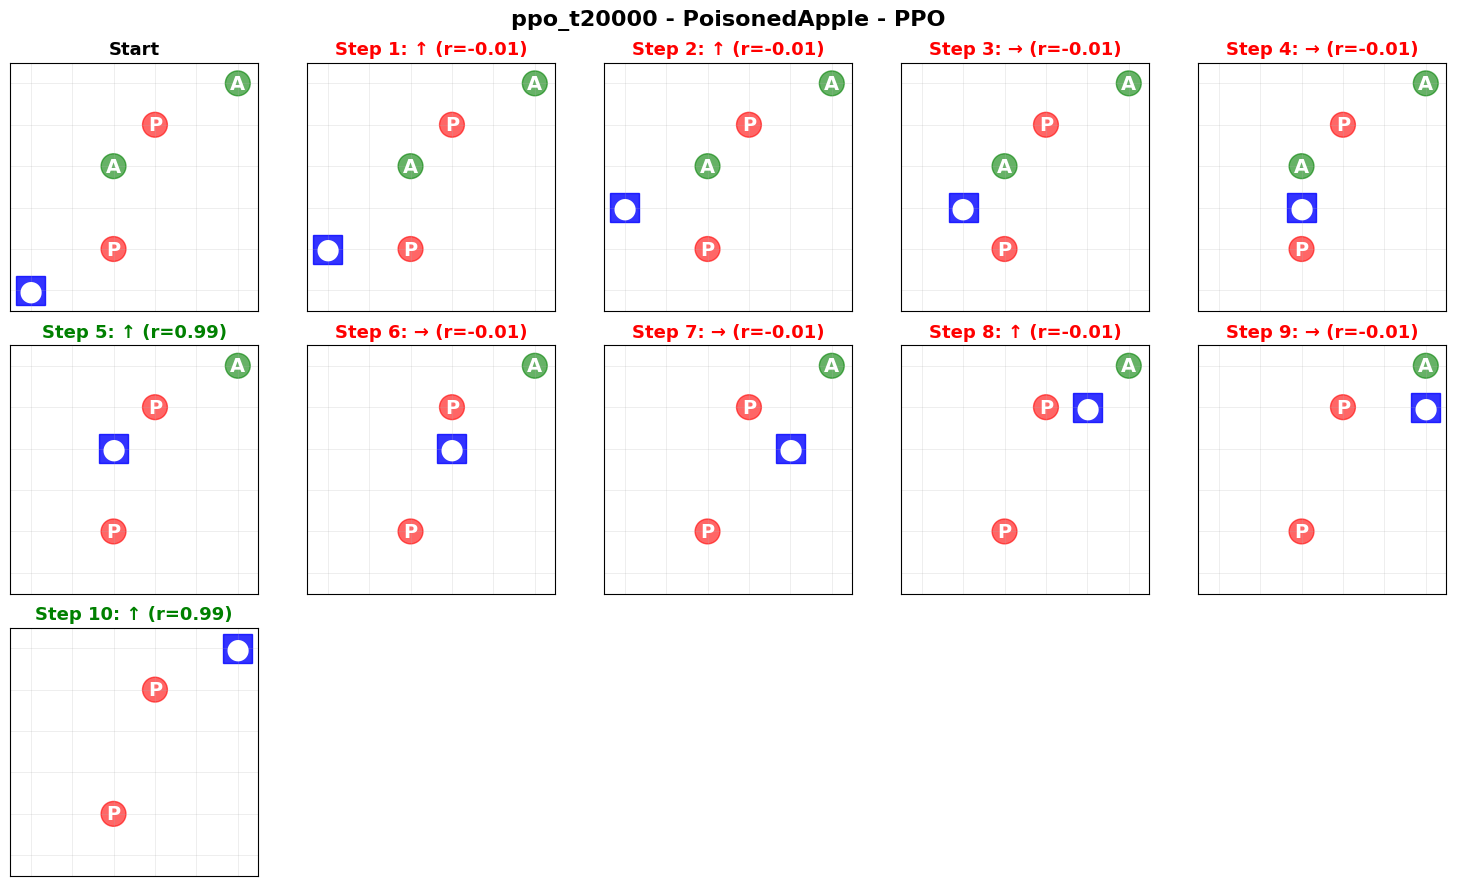

In [7]:
max_rollout_steps = 64
plot_trajectory = True
save_dir = None
timesteps = 20_000
seed = 42
device = "cpu"
render_mode = "human"

actor, _ = train_policy(
    total_timesteps=timesteps,
    seed=seed,
    device=device,
)

eval_env = build_env(render_mode=None)
mean_r, std_r, failure_rate = evaluate(
    env=eval_env,
    actor=actor,
    episodes=50,
    seed=seed,
    device=device,
    deterministic=True,
    render_mode=None,
)
eval_env.close()

print(
    f"Post-train evaluation: mean_reward={mean_r:.2f} +/- {std_r:.2f}, "
    f"failure_rate={failure_rate:.2f}"
)

rollout_and_render(
    actor=actor,
    seed=seed,
    render_mode=render_mode,
    max_steps=max_rollout_steps,
)

if plot_trajectory:
    maybe_plot_trajectory(
        actor=actor,
        save_dir=save_dir,
        cfg_name=f"ppo_t{timesteps}",
    )

### Save behaviour demonstrations

In [2]:
import numpy as np
import torch
from torch.utils.data import TensorDataset

from poisoned_apple_env import (
    PoisonedAppleEnv,
    get_safety_critical_observations_and_safe_actions,
    plot_safety_dataset_on_grid
)

# 1) Build a fixed-layout env (flat observations required)
env = PoisonedAppleEnv(
    grid_size=4,
    num_apples=3,
    num_poisoned=1,
    agent_start_pos=(3, 0),
    safe_apple_positions=[(0, 0), (0, 3)],
    poisoned_apple_positions=[(2, 2)],
    observation_type="flat",
    max_steps=20,
)

# 2) Reset once to instantiate the layout
env.reset(seed=0)

# 3) Get safety-critical states and safe actions
critical = get_safety_critical_observations_and_safe_actions(env)

print(f"num safety-critical states: {len(critical)}")
for i, (obs, safe_actions) in enumerate(critical[:5]):
    agent_idx = int(np.flatnonzero(obs == 1.0)[0])
    row, col = divmod(agent_idx, env.grid_size)
    print(f"{i}: agent=({row},{col}), safe_actions={safe_actions}")

# 4) Convert to a training dataset (multi-hot labels over actions)
X = torch.tensor(np.stack([obs for obs, _ in critical]), dtype=torch.float32)
Y = torch.zeros((len(critical), env.action_space.n), dtype=torch.float32)
for i, (_, safe_actions) in enumerate(critical):
    Y[i, safe_actions] = 1.0

safety_dataset = TensorDataset(X, Y)
print("dataset shapes:", X.shape, Y.shape)

env.close()


num safety-critical states: 4
0: agent=(1,2), safe_actions=[0, 1, 3]
1: agent=(2,1), safe_actions=[0, 2, 3]
2: agent=(2,3), safe_actions=[0, 1, 2]
3: agent=(3,2), safe_actions=[1, 2, 3]
dataset shapes: torch.Size([4, 16]) torch.Size([4, 4])


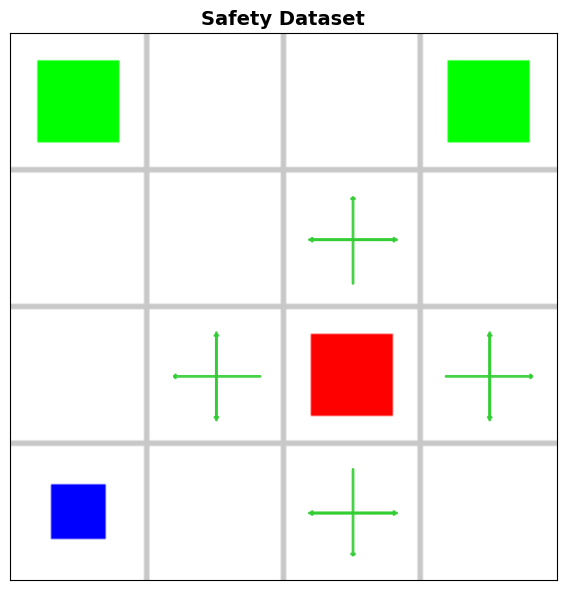

In [3]:
critical = get_safety_critical_observations_and_safe_actions(env)
fig = plot_safety_dataset_on_grid(env, critical, title="Safety Dataset")